In [78]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import pickle
from pathlib import Path

#all_trials = pd.read_parquet(Path("notebook_outputs") / "all_trials_cached.parquet")

In [79]:
# Load Q2 results before starting Q3

import pickle

with open("notebook_outputs/q2_workspace.pkl", "rb") as f:
    globals().update(pickle.load(f))

In [80]:
# Workspace save/load helpers

import pickle
import types
from pathlib import Path

def save_workspace(stage_name, output_folder="notebook_outputs"):
    output_dir = Path(output_folder)
    output_dir.mkdir(exist_ok=True)

    workspace = {}

    for name, value in list(globals().items()):
        if name.startswith("_"):
            continue
        if name.endswith("_workspace"):
            continue
        if name in ["In", "Out", "get_ipython", "exit", "quit"]:
            continue
        if isinstance(value, types.ModuleType):
            continue
        if callable(value):
            continue

        try:
            pickle.dumps(value)
            workspace[name] = value
        except Exception:
            pass

    file_path = output_dir / f"{stage_name}_workspace.pkl"

    with open(file_path, "wb") as f:
        pickle.dump(workspace, f)

    print(f"Saved {len(workspace)} variables to {file_path}")
    print(sorted(workspace.keys()))


def load_workspace(stage_name, output_folder="notebook_outputs"):
    file_path = Path(output_folder) / f"{stage_name}_workspace.pkl"

    with open(file_path, "rb") as f:
        workspace = pickle.load(f)

    globals().update(workspace)

    print(f"Loaded {len(workspace)} variables from {file_path}")
    print(sorted(workspace.keys()))

## Q3. Choice history

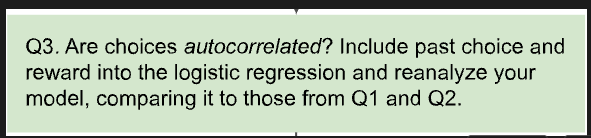

# Q3. Are choices autocorrelated?

### Are the mouse’s choices influenced by past trials?

In Q1, the model used only current stimulus contrast: `choice ~ signed_contrast`

In Q2, the model added lapse probability: `choice ~ signed_contrast + lapse`

In Q3, we need to add behavioral history: `choice ~ signed_contrast + previous_choice + previous_reward`

- `previous_choice` -> what the mouse chose on the previous trial

- `previous_reward` -> whether the mouse was rewarded/correct on the previous trial

Then compare Q3 with Q1 and Q2 using log-likelihood.

If Q3 has better log-likelihood, it means past choice/reward helps predict current choice. 

That would suggest choices are autocorrelated.

### Q3-1. Preparing Previous-Trial Columns for Q3 

- For Q3, I make a new copy called `df_q3` and add past-trial columns only to this copy.

- sort the trials in time order. `sorting` is important because `shift(1)` takes the row directly above as the prev trial.

- group by subject and session so previous trials are calculated separately within each mouse and session.

-  `prev_choice_binary` from the previous trial’s choice.

- `prev_rewarded` from the previous trial’s feedback.

-  remove the first trial of each session because it has no previous trial. 



In [81]:
# Create Q3 copy. Do not change df_q1.
df_q3 = df_q1.copy(deep=True)

#We sort trials are sorted by subject, session_start_time, session, and intervals_0 so the previous-trial columns are calculated in the correct time order.
sort_columns_q3 = [
    col for col in ['subject', 'session_start_time', 'session', 'intervals_0']
    if col in df_q3.columns
]
df_q3 = df_q3.sort_values(sort_columns_q3).copy(deep=True)


# create previous choice column for each mouse and session.
df_q3['prev_choice_binary'] = (
    df_q3
    .groupby(['subject', 'session'])['choice_binary']
    .shift(1)            #shift(1) moves the choices down by one row, so each trial gets the choice from the trial before it

)

# Create previous feedback column for each mouse and session. feedbackType = 0/1 here both
df_q3['prev_feedbackType'] = (
    df_q3
    .groupby(['subject', 'session'])['feedbackType']
    .shift(1)
)

# Convert previous reward to binary:
                            # previous rewarded trial = 1
                            # previous unrewarded/error trial = 0
df_q3['prev_rewarded'] = (df_q3['prev_feedbackType'] == 1).astype(float)

# Remove trials with no previous trial information.
df_q3_model = df_q3.loc[
      df_q3['prev_choice_binary'].notna() &
      df_q3['prev_feedbackType'].notna()
].copy(deep=True)

# Convert previous choice/reward to integer 0/1.
df_q3_model['prev_choice_binary'] = df_q3_model['prev_choice_binary'].astype(int)
df_q3_model['prev_rewarded'] = df_q3_model['prev_rewarded'].astype(int)

display(
    df_q3_model[[
        'subject',
        'session',
        'signed_contrast',
        'choice_binary',
        'prev_choice_binary',
        'prev_rewarded'
    ]].head()
)

print('Q1 rows:', len(df_q1))
print('Q3 rows after removing first trial of each session:', len(df_q3_model))


,subject,session,signed_contrast,choice_binary,prev_choice_binary,prev_rewarded
41825,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,0.0625,1,1,0
41826,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,-0.1250,1,1,1
41827,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,-0.0000,1,1,0
41828,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,-0.0000,0,1,0
41829,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,-0.2500,0,0,1


Q1 rows: 2132658
Q3 rows after removing first trial of each session: 2129698


In [82]:
# Add behavior type: win-stay / win-shift / lose-stay / lose-shift

df_q3_model['behavior_type'] = 'unknown'

# rewarded previous trial + same choice now
df_q3_model.loc[
    (df_q3_model['prev_rewarded'] == 1) &
    (df_q3_model['choice_binary'] == df_q3_model['prev_choice_binary']),
    'behavior_type'
] = 'win-stay'

# rewarded previous trial + switched choice now
df_q3_model.loc[
    (df_q3_model['prev_rewarded'] == 1) &
    (df_q3_model['choice_binary'] != df_q3_model['prev_choice_binary']),
    'behavior_type'
] = 'win-shift'

# unrewarded previous trial + same choice now
df_q3_model.loc[
    (df_q3_model['prev_rewarded'] == 0) &
    (df_q3_model['choice_binary'] == df_q3_model['prev_choice_binary']),
    'behavior_type'
] = 'lose-stay'

# unrewarded previous trial + switched choice now
df_q3_model.loc[
    (df_q3_model['prev_rewarded'] == 0) &
    (df_q3_model['choice_binary'] != df_q3_model['prev_choice_binary']),
    'behavior_type'
] = 'lose-shift'

display(
    df_q3_model[
        [
            'subject',
            'session',
            'signed_contrast',
            'choice_binary',
            'prev_choice_binary',
            'prev_rewarded',
            'behavior_type'
        ]
    ].head(20)
)


print('Q1 rows:', len(df_q1))
print('Q3 rows after removing first trial of each session:', len(df_q3_model))

,subject,session,signed_contrast,choice_binary,prev_choice_binary,prev_rewarded,behavior_type
41825,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,0.0625,1,1,0,lose-stay
41826,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,-0.1250,1,1,1,win-stay
41827,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,-0.0000,1,1,0,lose-stay
41828,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,-0.0000,0,1,0,lose-shift
41829,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,-0.2500,0,0,1,win-stay
41830,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,-0.1250,0,0,1,win-stay
41831,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,0.1250,1,0,1,win-shift
41832,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,0.1250,1,1,1,win-stay
41833,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,0.0000,0,1,1,win-shift
41834,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,-1.0000,0,0,0,lose-stay


Q1 rows: 2132658
Q3 rows after removing first trial of each session: 2129698


### Q3-2. Fit logistic regression with past choice and reward

For each mouse separately, we train a new logistic regression model.

Input variables:

- `signed_contrast`

- `prev_choice_binary`

- `prev_rewarded`

Target variable:

- `choice_binary`

Important interpretation:

- If `prev_choice_weight` is positive, then the mouse tends to repeat the previous choice.

- If `prev_choice_weight` is negative, then the mouse tends to switch away from the previous choice.


In [83]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss


mouse_models_q3 = {}

for subject, mouse_data in df_q3_model.groupby('subject'):

    X_q3 = mouse_data[['signed_contrast', 'prev_choice_binary',  'prev_rewarded']]

    y_q3 = mouse_data['choice_binary']

    # Skip a mouse if it does not have both choice classes after preprocessing.
    if y_q3.nunique() < 2:
        continue

    #training 80% of data 
    X_train_q3, X_test_q3, y_train_q3, y_test_q3 = train_test_split(
        X_q3,
        y_q3,
        test_size=0.2,
        random_state=0,
        stratify=y_q3
    )

    model_q3 = LogisticRegression()
    model_q3.fit(X_train_q3, y_train_q3)
    
    class_1_index_q3 = list(model_q3.classes_).index(1)

    #predict testign data 
    p_test_q3 = model_q3.predict_proba(X_test_q3)[:, class_1_index_q3]

    #evaluation testign data 
    log_likelihood_q3 = -log_loss( y_test_q3,  p_test_q3,  labels=[0, 1] )

    mouse_models_q3[subject] = {
        'model': model_q3,
        'X_train': X_train_q3,
        'X_test': X_test_q3,
        'y_train': y_train_q3,
        'y_test': y_test_q3,
        'p_test_q3': p_test_q3,
        'log_likelihood_q3': log_likelihood_q3,
        'bias_q3': model_q3.intercept_[0],
        'contrast_weight_q3': model_q3.coef_[0][0],
        'prev_choice_weight': model_q3.coef_[0][1],
        'prev_reward_weight': model_q3.coef_[0][2]
    }

print('Number of Q3 mouse models:', len(mouse_models_q3))


Number of Q3 mouse models: 119


### Q3-3. Save Q3 model results in a new table

This table is new. It does not change `results_df`, `lapse_results_df`, or `comparison_df`.


In [84]:
q3_results = []

for subject, result in mouse_models_q3.items():
    q3_results.append({
        'subject': subject,
        'bias_q3': result['bias_q3'],
        'contrast_weight_q3': result['contrast_weight_q3'],
        'prev_choice_weight': result['prev_choice_weight'],
        'prev_reward_weight': result['prev_reward_weight'],
        'log_likelihood_q3': result['log_likelihood_q3']
    })

q3_results_df = pd.DataFrame(q3_results)

display(q3_results_df.head())


,subject,bias_q3,contrast_weight_q3,prev_choice_weight,prev_reward_weight,log_likelihood_q3
0,CSHL045,-1.063340,7.593490,1.845844,0.148076,-0.408899
1,CSHL046,-1.281008,4.859110,1.865794,0.372836,-0.434661
2,CSHL047,-1.272828,4.974601,1.416276,-0.561873,-0.410820
3,CSHL049,-0.403213,6.854520,1.457342,0.082990,-0.409152
4,CSHL051,-1.424229,3.490318,2.153235,-0.164136,-0.431315


### Q3-4. Are choices autocorrelated?

Here we look at the `prev_choice_weight`.

- Positive value means current choice depends positively on previous choice.

- Negative value means the mouse tends to switch choices.

- Values close to zero mean weak choice autocorrelation.


In [85]:
print('Mean previous choice weight:', q3_results_df['prev_choice_weight'].mean())
print('Median previous choice weight:', q3_results_df['prev_choice_weight'].median())
print('Number of mice with positive previous choice weight:', (q3_results_df['prev_choice_weight'] > 0).sum())
print('Number of mice with negative previous choice weight:', (q3_results_df['prev_choice_weight'] < 0).sum())


Mean previous choice weight: 1.5569872530736526
Median previous choice weight: 1.50156513693796
Number of mice with positive previous choice weight: 118
Number of mice with negative previous choice weight: 1


### Q3-5. Compare Q3 with Q1 and Q2

Now we compare the held-out log-likelihoods.

New table:

- `comparison_q1_q2_q3_df`

This is a copy-based merge and does not change the old comparison table.


In [86]:
comparison_q1_q2_q3_df = (
    comparison_df.copy(deep=True)
    .merge(q3_results_df, on='subject')
)

comparison_q1_q2_q3_df['q3_improvement_vs_q1'] = (
    comparison_q1_q2_q3_df['log_likelihood_q3']
    - comparison_q1_q2_q3_df['log_likelihood']
)

comparison_q1_q2_q3_df['q3_improvement_vs_q2'] = (
    comparison_q1_q2_q3_df['log_likelihood_q3']
    - comparison_q1_q2_q3_df['log_likelihood_lapse']
)

model_columns_q3 = [
    'log_likelihood',
    'log_likelihood_lapse',
    'log_likelihood_q3'
]

comparison_q1_q2_q3_df['best_model'] = (
    comparison_q1_q2_q3_df[model_columns_q3]
    .idxmax(axis=1)
    .replace({
        'log_likelihood': 'Q1 logistic',
        'log_likelihood_lapse': 'Q2 logistic + lapse',
        'log_likelihood_q3': 'Q3 history logistic'
    })
)

print('Mean Q1 log likelihood:', comparison_q1_q2_q3_df['log_likelihood'].mean())
print('Mean Q2 lapse log likelihood:', comparison_q1_q2_q3_df['log_likelihood_lapse'].mean())
print('Mean Q3 history log likelihood:', comparison_q1_q2_q3_df['log_likelihood_q3'].mean())
print()
print('Mean Q3 improvement vs Q1:', comparison_q1_q2_q3_df['q3_improvement_vs_q1'].mean())
print('Mean Q3 improvement vs Q2:', comparison_q1_q2_q3_df['q3_improvement_vs_q2'].mean())

display(
    comparison_q1_q2_q3_df[[
        'subject',
        'log_likelihood',
        'log_likelihood_lapse',
        'log_likelihood_q3',
        'q3_improvement_vs_q1',
        'q3_improvement_vs_q2',
        'best_model'
    ]].head()
)


Mean Q1 log likelihood: -0.4816715549986881
Mean Q2 lapse log likelihood: -0.45166135297463095
Mean Q3 history log likelihood: -0.4278173880978828

Mean Q3 improvement vs Q1: 0.05385416690080529
Mean Q3 improvement vs Q2: 0.02384396487674817


,subject,log_likelihood,log_likelihood_lapse,log_likelihood_q3,q3_improvement_vs_q1,q3_improvement_vs_q2,best_model
0,CSHL045,-0.449487,-0.427553,-0.408899,0.040588,0.018654,Q3 history logistic
1,CSHL046,-0.511274,-0.480282,-0.434661,0.076613,0.045621,Q3 history logistic
2,CSHL047,-0.427543,-0.406147,-0.410820,0.016723,-0.004673,Q2 logistic + lapse
3,CSHL049,-0.459950,-0.419311,-0.409152,0.050797,0.010159,Q3 history logistic
4,CSHL051,-0.535279,-0.516941,-0.431315,0.103964,0.085626,Q3 history logistic


### Q3-6. Visualize model comparison

This plot compares Q1, Q2, and Q3 log-likelihoods across mice.

A value closer to `0` is better.


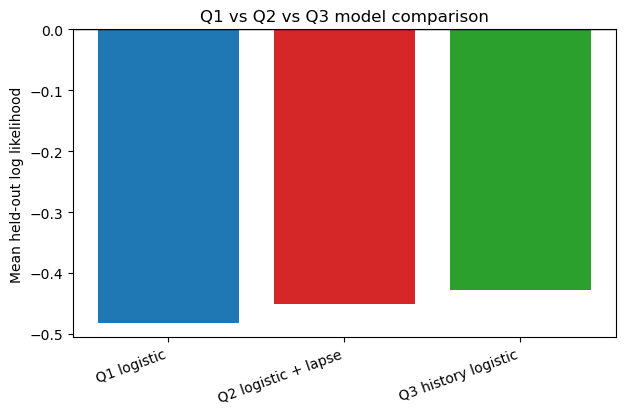

,model,mean_log_likelihood
0,Q1 logistic,-0.481672
1,Q2 logistic + lapse,-0.451661
2,Q3 history logistic,-0.427817


In [87]:
mean_model_scores_q3 = pd.DataFrame({
    'model': [
        'Q1 logistic',
        'Q2 logistic + lapse',
        'Q3 history logistic'
    ],
    'mean_log_likelihood': [
        comparison_q1_q2_q3_df['log_likelihood'].mean(),
        comparison_q1_q2_q3_df['log_likelihood_lapse'].mean(),
        comparison_q1_q2_q3_df['log_likelihood_q3'].mean()
    ]
})

plt.figure(figsize=(7, 4))
plt.bar(
    mean_model_scores_q3['model'],
    mean_model_scores_q3['mean_log_likelihood'],
    color=['tab:blue', 'tab:red', 'tab:green']
)
plt.ylabel('Mean held-out log likelihood')
plt.title('Q1 vs Q2 vs Q3 model comparison')
plt.xticks(rotation=20, ha='right')
plt.axhline(0, color='black', linewidth=1)
plt.show()

display(mean_model_scores_q3)


## Q3 interaction: previous choice x previous reward

If `prev_choice_weight` is mostly positive, then choices are autocorrelated: the previous choice helps predict the current choice.

If Q3 has higher log-likelihood than Q1 and Q2, then adding past choice and reward improved prediction.

If Q3 does not improve log-likelihood, then the history variables do not improve the held-out prediction for this dataset/model version.


### Q3-7. Add previous_choice x previous_reward interaction

This is a copy-based extension of Q3.

The original Q3 model tested whether previous choice and previous reward separately help predict current choice:

```text
choice ~ signed_contrast + previous_choice + previous_reward
```

Now we add an interaction:

```text
choice ~ signed_contrast + previous_choice + previous_reward + previous_choice x previous_reward
```

What this gives us:

- It tests whether the effect of previous choice depends on whether the previous trial was rewarded.

- Positive interaction means previous-choice repetition is stronger after reward, like a win-stay effect.

- Negative interaction means reward weakens previous-choice repetition, or unrewarded trials create stronger history effects.

- If the interaction improves held-out log likelihood, then this richer history model predicts behavior better than original Q3.

I use centered variables for the interaction:

```text
previous choice: 0/1 becomes -1/+1

previous reward: 0/1 becomes -1/+1
```

This makes the interaction coefficient easier to interpret.


In [88]:
# Q3 interaction copy. Do not change df_q3_model or old Q3 results.

df_q3_interaction = df_q3_model.copy(deep=True)

df_q3_interaction['prev_choice_centered'] = (
    df_q3_interaction['prev_choice_binary'].astype(float) * 2 - 1
)

df_q3_interaction['prev_reward_centered'] = (
    df_q3_interaction['prev_rewarded'].astype(float) * 2 - 1
)

df_q3_interaction['prev_choice_x_reward'] = (
    df_q3_interaction['prev_choice_centered']
    * df_q3_interaction['prev_reward_centered']
)

q3_interaction_feature_columns = [
    'signed_contrast',
    'prev_choice_centered',
    'prev_reward_centered',
    'prev_choice_x_reward'
]

display(
    df_q3_interaction[[
        'subject',
        'session',
        'choice_binary',
        'signed_contrast',
        'prev_choice_binary',
        'prev_rewarded',
        'prev_choice_centered',
        'prev_reward_centered',
        'prev_choice_x_reward'
    ]].head()
)

print('Q3 interaction data shape:', df_q3_interaction.shape)


,subject,session,choice_binary,signed_contrast,prev_choice_binary,prev_rewarded,prev_choice_centered,prev_reward_centered,prev_choice_x_reward
41825,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,1,0.0625,1,0,1.0,-1.0,-1.0
41826,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,1,-0.1250,1,1,1.0,1.0,1.0
41827,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,1,-0.0000,1,0,1.0,-1.0,-1.0
41828,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,0,-0.0000,1,0,1.0,-1.0,-1.0
41829,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,0,-0.2500,0,1,-1.0,1.0,-1.0


Q3 interaction data shape: (2129698, 43)


### Q3-8. Fit logistic regression with the interaction

The key new coefficient is:

```text
prev_choice_x_reward_weight
```

Interpretation:

- positive value: previous choice has stronger effect after reward

- negative value: previous choice has weaker effect after reward

- value near zero: little evidence that reward changes the previous-choice effect


In [89]:
mouse_models_q3_interaction = {}

for subject, mouse_data in df_q3_interaction.groupby('subject'):

    X_q3_interaction = mouse_data[q3_interaction_feature_columns]
    y_q3_interaction = mouse_data['choice_binary']

    if y_q3_interaction.nunique() < 2:
        continue

    X_train_q3_interaction, X_test_q3_interaction, y_train_q3_interaction, y_test_q3_interaction = train_test_split(
        X_q3_interaction,
        y_q3_interaction,
        test_size=0.2,
        random_state=0,
        stratify=y_q3_interaction
    )

    model_q3_interaction = LogisticRegression(max_iter=1000)
    model_q3_interaction.fit(X_train_q3_interaction, y_train_q3_interaction)

    class_1_index_q3_interaction = list(model_q3_interaction.classes_).index(1)
    p_test_q3_interaction = model_q3_interaction.predict_proba(X_test_q3_interaction)[:, class_1_index_q3_interaction]

    log_likelihood_q3_interaction = -log_loss(
        y_test_q3_interaction,
        p_test_q3_interaction,
        labels=[0, 1]
    )

    mouse_models_q3_interaction[subject] = {
        'model': model_q3_interaction,
        'X_train': X_train_q3_interaction,
        'X_test': X_test_q3_interaction,
        'y_train': y_train_q3_interaction,
        'y_test': y_test_q3_interaction,
        'p_test_q3_interaction': p_test_q3_interaction,
        'log_likelihood_q3_interaction': log_likelihood_q3_interaction,
        'bias_q3_interaction': model_q3_interaction.intercept_[0],
        'contrast_weight_q3_interaction': model_q3_interaction.coef_[0][0],
        'prev_choice_weight_centered': model_q3_interaction.coef_[0][1],
        'prev_reward_weight_centered': model_q3_interaction.coef_[0][2],
        'prev_choice_x_reward_weight': model_q3_interaction.coef_[0][3]
    }

print('Number of Q3 interaction mouse models:', len(mouse_models_q3_interaction))


Number of Q3 interaction mouse models: 119


### Q3-9. Save Q3 interaction results

This creates a new table and does not overwrite `q3_results_df`.


In [90]:
q3_interaction_results = []

for subject, result in mouse_models_q3_interaction.items():
    q3_interaction_results.append({
        'subject': subject,
        'bias_q3_interaction': result['bias_q3_interaction'],
        'contrast_weight_q3_interaction': result['contrast_weight_q3_interaction'],
        'prev_choice_weight_centered': result['prev_choice_weight_centered'],
        'prev_reward_weight_centered': result['prev_reward_weight_centered'],
        'prev_choice_x_reward_weight': result['prev_choice_x_reward_weight'],
        'log_likelihood_q3_interaction': result['log_likelihood_q3_interaction']
    })

q3_interaction_results_df = pd.DataFrame(q3_interaction_results)

display(q3_interaction_results_df.head())

print('Mean interaction weight:', q3_interaction_results_df['prev_choice_x_reward_weight'].mean())
print('Median interaction weight:', q3_interaction_results_df['prev_choice_x_reward_weight'].median())
print('Mice with positive interaction:', (q3_interaction_results_df['prev_choice_x_reward_weight'] > 0).sum())
print('Mice with negative interaction:', (q3_interaction_results_df['prev_choice_x_reward_weight'] < 0).sum())


,subject,bias_q3_interaction,contrast_weight_q3_interaction,prev_choice_weight_centered,prev_reward_weight_centered,prev_choice_x_reward_weight,log_likelihood_q3_interaction
0,CSHL045,-0.063551,7.469667,0.768717,0.073065,0.267086,-0.406107
1,CSHL046,-0.154665,4.783540,0.851215,0.181728,0.154878,-0.430546
2,CSHL047,-0.835128,4.981961,0.721053,-0.291670,-0.018169,-0.410913
3,CSHL049,0.399390,6.766843,0.644235,0.008783,0.144478,-0.408931
4,CSHL051,-0.479185,3.442646,0.983881,-0.037833,0.191089,-0.429854


Mean interaction weight: 0.11929365012978282
Median interaction weight: 0.13123408685016144
Mice with positive interaction: 100
Mice with negative interaction: 19


### Q3-10. Compare original Q3 vs Q3 with interaction

If the interaction model has higher held-out log likelihood, the combined history term adds useful predictive information.


In [91]:
comparison_q1_q2_q3_interaction_df = (
    comparison_q1_q2_q3_df.copy(deep=True)
    .merge(q3_interaction_results_df, on='subject')
)

comparison_q1_q2_q3_interaction_df['q3_interaction_improvement_vs_q3'] = (
    comparison_q1_q2_q3_interaction_df['log_likelihood_q3_interaction']
    - comparison_q1_q2_q3_interaction_df['log_likelihood_q3']
)

comparison_q1_q2_q3_interaction_df['q3_interaction_improvement_vs_q1'] = (
    comparison_q1_q2_q3_interaction_df['log_likelihood_q3_interaction']
    - comparison_q1_q2_q3_interaction_df['log_likelihood']
)

comparison_q1_q2_q3_interaction_df['q3_interaction_improvement_vs_q2'] = (
    comparison_q1_q2_q3_interaction_df['log_likelihood_q3_interaction']
    - comparison_q1_q2_q3_interaction_df['log_likelihood_lapse']
)

q3_interaction_model_columns = [
    'log_likelihood',
    'log_likelihood_lapse',
    'log_likelihood_q3',
    'log_likelihood_q3_interaction'
]

comparison_q1_q2_q3_interaction_df['best_model_with_interaction'] = (
    comparison_q1_q2_q3_interaction_df[q3_interaction_model_columns]
    .idxmax(axis=1)
    .replace({
        'log_likelihood': 'Q1 logistic',
        'log_likelihood_lapse': 'Q2 logistic + lapse',
        'log_likelihood_q3': 'Q3 history logistic',
        'log_likelihood_q3_interaction': 'Q3 history + interaction'
    })
)

print('Mean Q3 log likelihood:', comparison_q1_q2_q3_interaction_df['log_likelihood_q3'].mean())
print('Mean Q3 interaction log likelihood:', comparison_q1_q2_q3_interaction_df['log_likelihood_q3_interaction'].mean())
print('Mean improvement vs Q3:', comparison_q1_q2_q3_interaction_df['q3_interaction_improvement_vs_q3'].mean())
print('Mice improved vs Q3:', (comparison_q1_q2_q3_interaction_df['q3_interaction_improvement_vs_q3'] > 0).sum(), '/', len(comparison_q1_q2_q3_interaction_df))

display(
    comparison_q1_q2_q3_interaction_df[[
        'subject',
        'log_likelihood_q3',
        'log_likelihood_q3_interaction',
        'q3_interaction_improvement_vs_q3',
        'prev_choice_x_reward_weight',
        'best_model_with_interaction'
    ]].head()
)


Mean Q3 log likelihood: -0.4278173880978828
Mean Q3 interaction log likelihood: -0.42674689234925417
Mean improvement vs Q3: 0.001070495748628581
Mice improved vs Q3: 89 / 119


,subject,log_likelihood_q3,log_likelihood_q3_interaction,q3_interaction_improvement_vs_q3,prev_choice_x_reward_weight,best_model_with_interaction
0,CSHL045,-0.408899,-0.406107,0.002792,0.267086,Q3 history + interaction
1,CSHL046,-0.434661,-0.430546,0.004115,0.154878,Q3 history + interaction
2,CSHL047,-0.410820,-0.410913,-0.000093,-0.018169,Q2 logistic + lapse
3,CSHL049,-0.409152,-0.408931,0.000221,0.144478,Q3 history + interaction
4,CSHL051,-0.431315,-0.429854,0.001461,0.191089,Q3 history + interaction


### Q3-10b. Bar plot including Q3 interaction

This is the same model-comparison plot as Q3-6, but now it also includes the interaction model.

Important: this cell must run after `comparison_q1_q2_q3_interaction_df` is created.


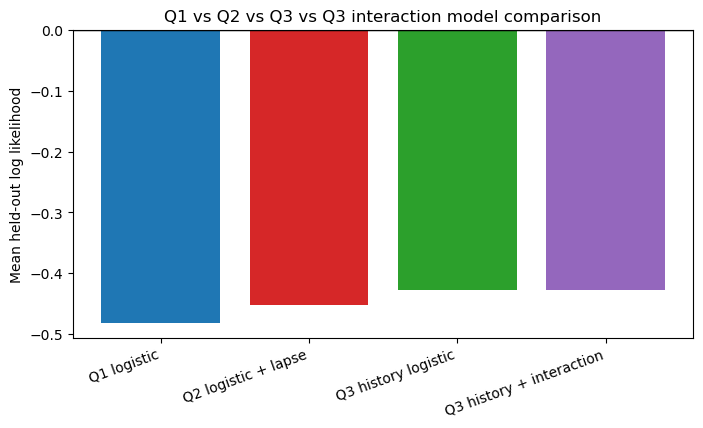

,model,mean_log_likelihood
0,Q1 logistic,-0.481672
1,Q2 logistic + lapse,-0.451661
2,Q3 history logistic,-0.427817
3,Q3 history + interaction,-0.426747


In [92]:
mean_model_scores_q3_interaction = pd.DataFrame({
    'model': [
        'Q1 logistic',
        'Q2 logistic + lapse',
        'Q3 history logistic',
        'Q3 history + interaction'
    ],
    'mean_log_likelihood': [
        comparison_q1_q2_q3_interaction_df['log_likelihood'].mean(),
        comparison_q1_q2_q3_interaction_df['log_likelihood_lapse'].mean(),
        comparison_q1_q2_q3_interaction_df['log_likelihood_q3'].mean(),
        comparison_q1_q2_q3_interaction_df['log_likelihood_q3_interaction'].mean()
    ]
})

plt.figure(figsize=(8, 4))
plt.bar(
    mean_model_scores_q3_interaction['model'],
    mean_model_scores_q3_interaction['mean_log_likelihood'],
    color=['tab:blue', 'tab:red', 'tab:green', 'tab:purple']
)
plt.ylabel('Mean held-out log likelihood')
plt.title('Q1 vs Q2 vs Q3 vs Q3 interaction model comparison')
plt.xticks(rotation=20, ha='right')
plt.axhline(0, color='black', linewidth=1)
plt.show()

display(mean_model_scores_q3_interaction)


### Q3-11. Visualize the interaction result

Left: distribution of interaction weights across mice.

Right: improvement of Q3 interaction model over original Q3.


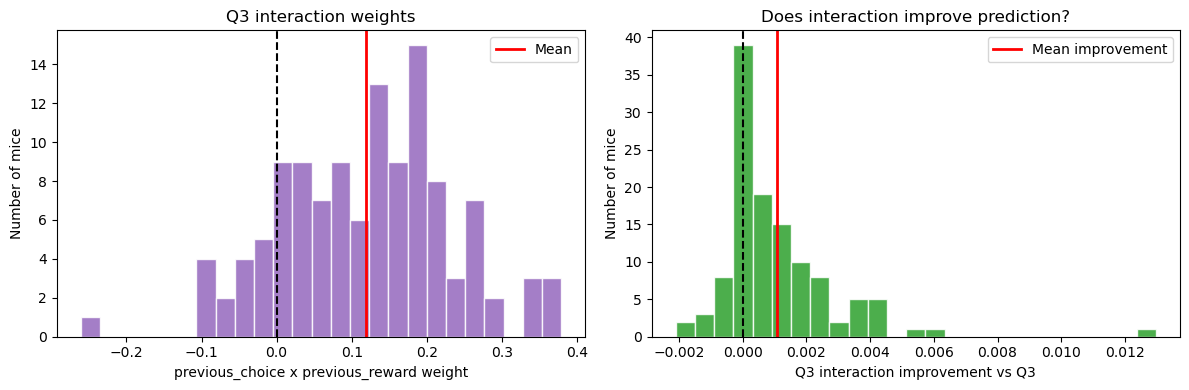

In [93]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(
    q3_interaction_results_df['prev_choice_x_reward_weight'],
    bins=25,
    color='tab:purple',
    edgecolor='white',
    alpha=0.85
)
axes[0].axvline(0, color='black', linestyle='--')
axes[0].axvline(
    q3_interaction_results_df['prev_choice_x_reward_weight'].mean(),
    color='red',
    linewidth=2,
    label='Mean'
)
axes[0].set_xlabel('previous_choice x previous_reward weight')
axes[0].set_ylabel('Number of mice')
axes[0].set_title('Q3 interaction weights')
axes[0].legend()

axes[1].hist(
    comparison_q1_q2_q3_interaction_df['q3_interaction_improvement_vs_q3'],
    bins=25,
    color='tab:green',
    edgecolor='white',
    alpha=0.85
)
axes[1].axvline(0, color='black', linestyle='--')
axes[1].axvline(
    comparison_q1_q2_q3_interaction_df['q3_interaction_improvement_vs_q3'].mean(),
    color='red',
    linewidth=2,
    label='Mean improvement'
)
axes[1].set_xlabel('Q3 interaction improvement vs Q3')
axes[1].set_ylabel('Number of mice')
axes[1].set_title('Does interaction improve prediction?')
axes[1].legend()

plt.tight_layout()
plt.show()


### Q3-12. Final interaction interpretation

This prints the short answer: what the interaction gives us.


In [94]:
mean_interaction_weight = q3_interaction_results_df['prev_choice_x_reward_weight'].mean()
mean_interaction_improvement = comparison_q1_q2_q3_interaction_df['q3_interaction_improvement_vs_q3'].mean()
n_positive_interaction = (q3_interaction_results_df['prev_choice_x_reward_weight'] > 0).sum()
n_total_interaction = len(q3_interaction_results_df)

print('Q3 interaction final answer')
print('---------------------------')
print('Mean previous_choice x previous_reward weight:', mean_interaction_weight)
print('Mean improvement over original Q3:', mean_interaction_improvement)
print('Mice with positive interaction:', n_positive_interaction, '/', n_total_interaction)
print()

if mean_interaction_weight > 0:
    print('Interpretation: previous choice has a stronger effect after rewarded trials.')
    print('This supports a win-stay-like history effect.')
elif mean_interaction_weight < 0:
    print('Interpretation: previous choice has a weaker effect after rewarded trials, or stronger effect after unrewarded trials.')
    print('This suggests history dependence is not simple win-stay behavior.')
else:
    print('Interpretation: the interaction is close to zero on average.')
    print('Previous choice and previous reward mostly act independently in this model.')

if mean_interaction_improvement > 0:
    print('Prediction: adding the interaction improves held-out log likelihood compared with original Q3.')
else:
    print('Prediction: adding the interaction does not improve held-out log likelihood compared with original Q3 on average.')

print()
print('What this term gives us:')
print('Original Q3 asks whether previous choice and previous reward matter separately.')
print('The interaction asks whether reward changes the effect of previous choice.')
print('So it tests a richer history strategy, especially win-stay / lose-shift-like behavior.')


Q3 interaction final answer
---------------------------
Mean previous_choice x previous_reward weight: 0.11929365012978282
Mean improvement over original Q3: 0.001070495748628581
Mice with positive interaction: 100 / 119

Interpretation: previous choice has a stronger effect after rewarded trials.
This supports a win-stay-like history effect.
Prediction: adding the interaction improves held-out log likelihood compared with original Q3.

What this term gives us:
Original Q3 asks whether previous choice and previous reward matter separately.
The interaction asks whether reward changes the effect of previous choice.
So it tests a richer history strategy, especially win-stay / lose-shift-like behavior.


#Q3 MY NOTES

**Lose-shift** значит:  

  если мышь **не получила reward**, она на следующем trial **меняет сторону**.

- Для этого нужны 3 колонки:

  - `prev_choice_binary` = что выбрала мышь на прошлом trial

  - `prev_rewarded` = получила ли reward на прошлом trial

  - `choice_binary` = что выбрала сейчас

- Мы проверяем:
  - прошлый trial был **not rewarded**

  - текущий choice **не такой**, как previous choice

- Если оба условия true:

```text
lose-shift-like behavior
```

- Пример:

| previous choice | previous reward | current choice | meaning |
|---|---|---|---|
| left | no reward | right | lose-shift |
| right | no reward | left | lose-shift |
| left | reward | left | win-stay |
| right | reward | right | win-stay |




```text
Lose-shift-like behavior means that after an unrewarded trial, the mouse switches to the opposite choice on the next trial.
```

In [95]:
import pickle
import types
from pathlib import Path

Path("notebook_outputs").mkdir(exist_ok=True)

workspace = {}

for name, value in list(globals().items()):
    if name.startswith("_"):
        continue
    if name in ["In", "Out", "exit", "quit", "get_ipython"]:
        continue
    if isinstance(value, types.ModuleType):
        continue
    if callable(value):
        continue

    try:
        pickle.dumps(value)
        workspace[name] = value
    except Exception:
        pass

with open("notebook_outputs/q3_workspace.pkl", "wb") as f:
    pickle.dump(workspace, f)

print("saved q3")

saved q3
